In [2]:
!pip install faker

   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   ---------------------------------------- 2.0/2.0 MB 21.7 MB/s eta 0:00:00


In [3]:
import pandas as pd
import random
from faker import Faker
from datetime import datetime, timedelta

# Initialize Faker and Seed for reproducibility
fake = Faker()
Faker.seed(4321)
random.seed(4321)

print("--- STARTING FORENSIC DATA GENERATION ---")

# ==========================================
# 1. GENERATE EMPLOYEES
# ==========================================
num_employees = 50
employees = []

for i in range(num_employees):
    employees.append({
        "Employee_ID": 1000 + i,
        "Name": fake.name(),
        "Address": fake.address().replace('\n', ', '),
        "Department": random.choice(['IT', 'Sales', 'Marketing', 'HR', 'Operations'])
    })

df_employees = pd.DataFrame(employees)
print(f"Generated {len(df_employees)} Employees.")

# ==========================================
# 2. GENERATE VENDORS (WITH INJECTED FRAUD)
# ==========================================
num_vendors = 100
vendors = []

for i in range(num_vendors):
    vendors.append({
        "Vendor_ID": 2000 + i,
        "Vendor_Name": fake.company(),
        "Vendor_Address": fake.address().replace('\n', ', '),
        "Tax_ID": fake.ein()
    })

# --- FRAUD INJECTION: GHOST VENDOR ---
# We force Vendor 2099 to have the SAME address as Employee 1005 (Conflict of Interest)
target_employee = df_employees.iloc[5] # Employee 1005
vendors.append({
    "Vendor_ID": 2099, # The Fraudulent Vendor
    "Vendor_Name": "Shell Corp Services",
    "Vendor_Address": target_employee['Address'], # MATCHING ADDRESS
    "Tax_ID": fake.ein()
})

df_vendors = pd.DataFrame(vendors)
print(f"Generated {len(df_vendors)} Vendors (including 1 Shell Company).")

# ==========================================
# 3. GENERATE EXPENSES (WITH INJECTED FRAUD)
# ==========================================
expenses = []
start_date = datetime(2023, 1, 1)
transaction_counter = 50000

# Helper to generate random dates
def random_date(start, end):
    return start + timedelta(days=random.randint(0, (end - start).days))

# A. Generate 1000 "Normal" Transactions
for _ in range(1000):
    emp = df_employees.sample(1).iloc[0]
    vend = df_vendors.sample(1).iloc[0]
    
    expenses.append({
        "Transaction_ID": transaction_counter,
        "Date": random_date(start_date, datetime(2023, 12, 31)),
        "Amount": round(random.uniform(50.00, 4500.00), 2),
        "Employee_ID": emp['Employee_ID'],
        "Vendor_ID": vend['Vendor_ID'],
        "Category": random.choice(['Travel', 'Supplies', 'Services', 'Meals', 'Software'])
    })
    transaction_counter += 1

# B. --- FRAUD INJECTION: SPLIT PAYMENTS (STRUCTURING) ---
# Scenario: Limit is $5000. Employee splits a $9000 invoice into two $4500 payments.
fraud_emp = df_employees.iloc[10]['Employee_ID'] # Employee 1010
fraud_vend = df_vendors.iloc[20]['Vendor_ID']    # Vendor 2020
split_date = datetime(2023, 6, 15) # A Thursday

# Payment 1
expenses.append({
    "Transaction_ID": transaction_counter,
    "Date": split_date,
    "Amount": 4500.00,
    "Employee_ID": fraud_emp,
    "Vendor_ID": fraud_vend,
    "Category": "Consulting"
})
transaction_counter += 1

# Payment 2 (Same day, slightly different time logic in real life, here same date)
expenses.append({
    "Transaction_ID": transaction_counter,
    "Date": split_date,
    "Amount": 4500.00,
    "Employee_ID": fraud_emp,
    "Vendor_ID": fraud_vend,
    "Category": "Consulting"
})
transaction_counter += 1

# C. --- FRAUD INJECTION: WEEKEND WARRIOR ---
# Force a transaction on a Sunday (July 2, 2023 was a Sunday)
expenses.append({
    "Transaction_ID": transaction_counter,
    "Date": datetime(2023, 7, 2),
    "Amount": 3800.00,
    "Employee_ID": df_employees.iloc[2]['Employee_ID'],
    "Vendor_ID": df_vendors.iloc[5]['Vendor_ID'],
    "Category": "Meals" # $3800 for meals on a Sunday? Red flag.
})

df_expenses = pd.DataFrame(expenses)

# Sort by date for realism
df_expenses = df_expenses.sort_values(by='Date').reset_index(drop=True)

print(f"Generated {len(df_expenses)} Expenses (including injected fraud patterns).")

# ==========================================
# 4. EXPORT TO CSV
# ==========================================
df_employees.to_csv('Employees.csv', index=False)
df_vendors.to_csv('Vendors.csv', index=False)
df_expenses.to_csv('Expenses.csv', index=False)

print("--- DATA GENERATION COMPLETE. FILES SAVED. ---")


--- STARTING FORENSIC DATA GENERATION ---
Generated 50 Employees.
Generated 101 Vendors (including 1 Shell Company).
Generated 1003 Expenses (including injected fraud patterns).
--- DATA GENERATION COMPLETE. FILES SAVED. ---


In [4]:
import sqlite3
import pandas as pd

print("--- STARTING ETL PROCESS ---")

# 1. CONNECT TO DATABASE
# This creates the file if it doesn't exist
conn = sqlite3.connect('Forensics_Lab.db')
cursor = conn.cursor()

# 2. LOAD CSV FILES
try:
    df_employees = pd.read_csv('Employees.csv')
    df_vendors = pd.read_csv('Vendors.csv')
    df_expenses = pd.read_csv('Expenses.csv')
    print("CSVs loaded into memory successfully.")
except FileNotFoundError:
    print("ERROR: Make sure the CSV files are in the same folder as this notebook!")

# 3. WRITE TO SQL
# if_exists='replace' ensures we don't duplicate data if we run this twice
df_employees.to_sql('Employees', conn, if_exists='replace', index=False)
df_vendors.to_sql('Vendors', conn, if_exists='replace', index=False)
df_expenses.to_sql('Expenses', conn, if_exists='replace', index=False)

print("Data pushed to SQL Database.")

# 4. VERIFY THE LOAD (Quality Assurance)
# We run a quick SQL count to ensure rows match
print("\n--- DATA INTEGRITY CHECK ---")
tables = ['Employees', 'Vendors', 'Expenses']
for table in tables:
    count = cursor.execute(f"SELECT COUNT(*) FROM {table}").fetchone()[0]
    print(f"Table '{table}': {count} rows loaded.")

# Close the connection meant for loading
conn.close()
print("\n--- ETL COMPLETE. DATABASE READY. ---")

--- STARTING ETL PROCESS ---
CSVs loaded into memory successfully.
Data pushed to SQL Database.

--- DATA INTEGRITY CHECK ---
Table 'Employees': 50 rows loaded.
Table 'Vendors': 101 rows loaded.
Table 'Expenses': 1003 rows loaded.

--- ETL COMPLETE. DATABASE READY. ---


In [5]:
import pandas as pd
import sqlite3

# Connect to the vault
conn = sqlite3.connect('Forensics_Lab.db')

# THE FORENSIC QUERY
# We use a CTE (Common Table Expression) called 'Ordered_Expenses' to prepare the data.
query = """
WITH Ordered_Expenses AS (
    SELECT 
        Transaction_ID,
        Date,
        Employee_ID,
        Vendor_ID,
        Amount,
        -- LAG looks at the PREVIOUS row for the same Employee/Vendor pair
        LAG(Date) OVER (PARTITION BY Employee_ID, Vendor_ID ORDER BY Date) as Prev_Date,
        LAG(Amount) OVER (PARTITION BY Employee_ID, Vendor_ID ORDER BY Date) as Prev_Amount,
        LAG(Transaction_ID) OVER (PARTITION BY Employee_ID, Vendor_ID ORDER BY Date) as Prev_Transaction_ID
    FROM Expenses
)
SELECT 
    Transaction_ID as Current_Trans_ID,
    Prev_Transaction_ID,
    Employee_ID, 
    Vendor_ID, 
    Date as Current_Date, 
    Prev_Date, 
    Amount as Current_Amt, 
    Prev_Amount,
    (Amount + Prev_Amount) as Total_Split_Value
FROM Ordered_Expenses
WHERE 
    Date = Prev_Date -- The smoking gun: Two transactions, same day, same people.
    AND Employee_ID IS NOT NULL
"""

print("--- EXECUTING SPLIT PAYMENT DETECTION ---")
df_split_payments = pd.read_sql_query(query, conn)

# Display the findings
if not df_split_payments.empty:
    print(f"RED FLAGS FOUND: {len(df_split_payments)} suspicious split transactions.")
    print(df_split_payments.to_string()) # to_string() prints the whole dataframe nicely
else:
    print("No split payments found.")

conn.close()

--- EXECUTING SPLIT PAYMENT DETECTION ---
RED FLAGS FOUND: 1 suspicious split transactions.
   Current_Trans_ID  Prev_Transaction_ID  Employee_ID  Vendor_ID Current_Date   Prev_Date  Current_Amt  Prev_Amount  Total_Split_Value
0             51001                51000         1010       2020   2023-06-15  2023-06-15       4500.0       4500.0             9000.0


In [6]:
import pandas as pd
import sqlite3

conn = sqlite3.connect('Forensics_Lab.db')

# THE FORENSIC QUERY
# We look for records where the address string is identical.
query = """
SELECT 
    e.Employee_ID,
    e.Name as Employee_Name,
    e.Address as Employee_Address,
    v.Vendor_ID,
    v.Vendor_Name,
    v.Vendor_Address,
    v.Tax_ID
FROM Employees e
JOIN Vendors v 
    ON e.Address = v.Vendor_Address -- The Link: Matching Addresses
"""

print("--- EXECUTING GHOST VENDOR DETECTION ---")
df_ghosts = pd.read_sql_query(query, conn)

if not df_ghosts.empty:
    print(f"CRITICAL ALERT: {len(df_ghosts)} Employee-Vendor conflicts found.")
    print(df_ghosts.to_string())
else:
    print("No address matches found.")

conn.close()

--- EXECUTING GHOST VENDOR DETECTION ---
CRITICAL ALERT: 1 Employee-Vendor conflicts found.
   Employee_ID Employee_Name                                    Employee_Address  Vendor_ID          Vendor_Name                                      Vendor_Address      Tax_ID
0         1005    Dean Welch  33581 Goodwin Islands, Lake Jeffreyshire, RI 15330       2099  Shell Corp Services  33581 Goodwin Islands, Lake Jeffreyshire, RI 15330  95-6688795


In [7]:
import pandas as pd
import sqlite3

conn = sqlite3.connect('Forensics_Lab.db')

# THE FORENSIC QUERY
# We filter for Day 0 (Sunday) or Day 6 (Saturday)
query = """
SELECT 
    Transaction_ID,
    Date,
    CASE 
        WHEN strftime('%w', Date) = '0' THEN 'Sunday'
        WHEN strftime('%w', Date) = '6' THEN 'Saturday'
    END as Day_of_Week,
    Employee_ID,
    Vendor_ID,
    Category,
    Amount
FROM Expenses
WHERE 
    strftime('%w', Date) IN ('0', '6') -- Filter for weekends
    AND Amount > 500 -- Ignore small coffees; look for big ticket items
ORDER BY Amount DESC
"""

print("--- EXECUTING WEEKEND SPEND ANALYSIS ---")
df_weekend = pd.read_sql_query(query, conn)

if not df_weekend.empty:
    print(f"ALARM: {len(df_weekend)} high-value weekend transactions found.")
    print(df_weekend.to_string())
else:
    print("No significant weekend spending found.")

conn.close()

--- EXECUTING WEEKEND SPEND ANALYSIS ---
ALARM: 261 high-value weekend transactions found.
     Transaction_ID        Date Day_of_Week  Employee_ID  Vendor_ID  Category   Amount
0             50988  2023-12-23    Saturday         1036       2085    Travel  4491.43
1             50728  2023-04-09      Sunday         1044       2029    Travel  4489.37
2             50233  2023-07-02      Sunday         1006       2036  Software  4479.86
3             50943  2023-02-12      Sunday         1047       2075  Software  4474.86
4             50879  2023-06-25      Sunday         1019       2002  Software  4472.42
5             50171  2023-02-25    Saturday         1035       2031  Software  4455.56
6             50467  2023-07-15    Saturday         1036       2094    Travel  4404.51
7             50632  2023-11-11    Saturday         1018       2044  Software  4399.18
8             50390  2023-07-01    Saturday         1021       2025  Software  4364.43
9             50665  2023-07-29    Satu

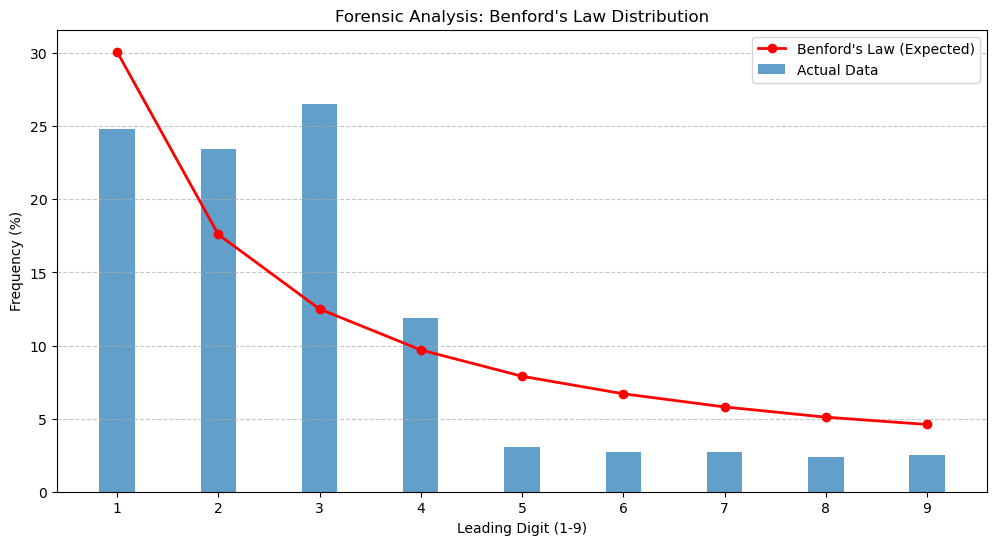

--- DIGIT DEVIATION REPORT ---
Digit | Actual %   | Expected % | Diff %    
---------------------------------------------
1     | 24.83      | 30.10      | -5.27      <== ANOMALY
2     | 23.43      | 17.60      | 5.83       <== ANOMALY
3     | 26.52      | 12.50      | 14.02      <== ANOMALY
4     | 11.86      | 9.70       | 2.16      
5     | 3.09       | 7.90       | -4.81      <== ANOMALY
6     | 2.69       | 6.70       | -4.01      <== ANOMALY
7     | 2.69       | 5.80       | -3.11      <== ANOMALY
8     | 2.39       | 5.10       | -2.71     
9     | 2.49       | 4.60       | -2.11     


In [8]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import numpy as np

conn = sqlite3.connect('Forensics_Lab.db')

# 1. GET THE DATA
df = pd.read_sql_query("SELECT Amount FROM Expenses WHERE Amount > 0", conn)

# 2. EXTRACT LEADING DIGIT
# Convert to string, strip whitespace, take first character, convert back to int
df['First_Digit'] = df['Amount'].astype(str).str[0].astype(int)

# Filter out 0 if any (Benford applies to 1-9)
df = df[df['First_Digit'].isin(range(1, 10))]

# 3. CALCULATE FREQUENCIES
# Actual counts
actual_counts = df['First_Digit'].value_counts(normalize=True).sort_index() * 100

# Expected Benford percentages
benford_probs = {
    1: 30.1, 2: 17.6, 3: 12.5, 4: 9.7, 
    5: 7.9,  6: 6.7,  7: 5.8,  8: 5.1,  9: 4.6
}
expected_counts = pd.Series(benford_probs)

# 4. VISUALIZE
plt.figure(figsize=(12, 6))
bar_width = 0.35
index = np.arange(1, 10)

# Plot Actuals (Blue bars)
plt.bar(index, actual_counts, bar_width, label='Actual Data', color='#1f77b4', alpha=0.7)

# Plot Expected (Orange line/markers)
plt.plot(index, expected_counts, color='red', marker='o', linestyle='-', linewidth=2, label="Benford's Law (Expected)")

plt.xlabel('Leading Digit (1-9)')
plt.ylabel('Frequency (%)')
plt.title("Forensic Analysis: Benford's Law Distribution")
plt.xticks(index)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

# 5. PRINT THE DEVIATIONS
print("--- DIGIT DEVIATION REPORT ---")
print(f"{'Digit':<5} | {'Actual %':<10} | {'Expected %':<10} | {'Diff %':<10}")
print("-" * 45)
for d in range(1, 10):
    act = actual_counts.get(d, 0)
    exp = expected_counts[d]
    diff = act - exp
    # Flag significant deviations (e.g., > 3%)
    flag = " <== ANOMALY" if abs(diff) > 3.0 else ""
    print(f"{d:<5} | {act:<10.2f} | {exp:<10.2f} | {diff:<10.2f}{flag}")

conn.close()

In [9]:
import pandas as pd
import sqlite3
import numpy as np

conn = sqlite3.connect('Forensics_Lab.db')

# 1. LOAD DATA
df_exp = pd.read_sql_query("SELECT * FROM Expenses", conn)
df_emp = pd.read_sql_query("SELECT Employee_ID, Address FROM Employees", conn)
df_ven = pd.read_sql_query("SELECT Vendor_ID, Vendor_Address FROM Vendors", conn)

# 2. SIMULATE GEOCODING (Adding Dummy Coordinates)
# We generate random coordinates roughly within the USA range (Lat 25-50, Lon -125 to -70)
np.random.seed(99) # Seed for consistency

def generate_coords(n):
    return {
        'Lat': np.random.uniform(25, 50, n),
        'Lon': np.random.uniform(-125, -70, n)
    }

# Add Coords to Employees
emp_coords = generate_coords(len(df_emp))
df_emp['Emp_Lat'] = emp_coords['Lat']
df_emp['Emp_Lon'] = emp_coords['Lon']

# Add Coords to Vendors
ven_coords = generate_coords(len(df_ven))
df_ven['Ven_Lat'] = ven_coords['Lat']
df_ven['Ven_Lon'] = ven_coords['Lon']

# 3. MERGE EVERYTHING (Expense + Emp Location + Vendor Location)
df_master = df_exp.merge(df_emp, on='Employee_ID').merge(df_ven, on='Vendor_ID')

# 4. THE HAVERSINE FORMULA (The "Math" of Distance)
def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # Radius of earth in kilometers
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlambda = np.radians(lon2 - lon1)
    
    a = np.sin(dphi/2)**2 + np.cos(phi1) * np.cos(phi2) * np.sin(dlambda/2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
    
    return R * c # Distance in KM

# Apply the math
df_master['Distance_KM'] = haversine(
    df_master['Emp_Lat'], df_master['Emp_Lon'],
    df_master['Ven_Lat'], df_master['Ven_Lon']
)

# 5. DETECT OUTLIERS
# Scenario A: The "Too Close" Risk (Potential Shell Company/Neighbor)
# Distance < 1km (Suspiciously close)
nearby_fraud = df_master[df_master['Distance_KM'] < 2]

print("--- GEOGRAPHIC RISK ANALYSIS ---")
if not nearby_fraud.empty:
    print(f"RISK FOUND: {len(nearby_fraud)} transactions where Vendor is < 2km from Employee.")
    # Show top 5 closest
    display_cols = ['Transaction_ID', 'Employee_ID', 'Vendor_ID', 'Distance_KM', 'Amount']
    print(nearby_fraud[display_cols].sort_values('Distance_KM').head(5).to_string(index=False))
else:
    print("No immediate geographic proximity risks found.")

# Scenario B: The "Too Far" Risk (Why buy coffee 3000km away?)
# Filter for 'Meals' > 2000km away (just as an example anomaly)
far_fraud = df_master[(df_master['Distance_KM'] > 3000) & (df_master['Category'] == 'Meals')]
print(f"\nLONG DISTANCE ANOMALIES: {len(far_fraud)} 'Meals' expenses > 3000km away.")

conn.close()

--- GEOGRAPHIC RISK ANALYSIS ---
No immediate geographic proximity risks found.

LONG DISTANCE ANOMALIES: 31 'Meals' expenses > 3000km away.


In [10]:
import pandas as pd
import sqlite3

conn = sqlite3.connect('Forensics_Lab.db')

# 1. LOAD MASTER DATA
df = pd.read_sql_query("""
    SELECT 
        e.Transaction_ID, e.Date, e.Amount, e.Category, 
        e.Employee_ID, emp.Name as Emp_Name, emp.Address as Emp_Address,
        e.Vendor_ID, ven.Vendor_Name, ven.Vendor_Address
    FROM Expenses e
    JOIN Employees emp ON e.Employee_ID = emp.Employee_ID
    JOIN Vendors ven ON e.Vendor_ID = ven.Vendor_ID
""", conn)

# INITIALIZE SCORE
df['Risk_Score'] = 0
df['Risk_Notes'] = ""

print(f"Loaded {len(df)} transactions for scoring...")

# ==========================================
# FLAG 1: GHOST VENDORS (+100 Points)
# ==========================================
# Logic: Employee Address == Vendor Address
mask_ghost = df['Emp_Address'] == df['Vendor_Address']
df.loc[mask_ghost, 'Risk_Score'] += 100
df.loc[mask_ghost, 'Risk_Notes'] += "Ghost_Vendor; "

# ==========================================
# FLAG 2: WEEKEND SPEND (+20 Points)
# ==========================================
# Logic: Date is Saturday (6) or Sunday (0) AND Amount > 500
df['Date'] = pd.to_datetime(df['Date']) # Ensure datetime format
df['DayOfWeek'] = df['Date'].dt.dayofweek # 0=Monday, 6=Sunday

mask_weekend = (df['DayOfWeek'].isin([5, 6])) & (df['Amount'] > 500)
# Note: Python's dayofweek is 0-6 (Mon-Sun), so Sat=5, Sun=6.
# SQL's strftime was 0-6 (Sun-Sat). We adjust for Python here.

df.loc[mask_weekend, 'Risk_Score'] += 20
df.loc[mask_weekend, 'Risk_Notes'] += "Weekend_High_Spend; "

# ==========================================
# FLAG 3: SPLIT PAYMENTS (+40 Points)
# ==========================================
# Logic: Same Emp, Same Ven, Same Date
# We re-calculate this using pandas shift()
df.sort_values(['Employee_ID', 'Vendor_ID', 'Date'], inplace=True)
df['Prev_Date'] = df.groupby(['Employee_ID', 'Vendor_ID'])['Date'].shift(1)
df['Prev_Amount'] = df.groupby(['Employee_ID', 'Vendor_ID'])['Amount'].shift(1)

mask_split = (df['Date'] == df['Prev_Date'])
df.loc[mask_split, 'Risk_Score'] += 40
# Also flag the previous row (the pair)
df.loc[df.index.isin(df[mask_split].index - 1), 'Risk_Score'] += 40 

df.loc[mask_split, 'Risk_Notes'] += "Split_Payment; "

# ==========================================
#

Loaded 1014 transactions for scoring...


In [11]:
import pandas as pd
import sqlite3

conn = sqlite3.connect('Forensics_Lab.db')

# 1. LOAD MASTER DATA
df = pd.read_sql_query("""
    SELECT 
        e.Transaction_ID, e.Date, e.Amount, e.Category, 
        e.Employee_ID, emp.Name as Emp_Name, emp.Address as Emp_Address,
        e.Vendor_ID, ven.Vendor_Name, ven.Vendor_Address
    FROM Expenses e
    JOIN Employees emp ON e.Employee_ID = emp.Employee_ID
    JOIN Vendors ven ON e.Vendor_ID = ven.Vendor_ID
""", conn)

# INITIALIZE SCORE
df['Risk_Score'] = 0
df['Risk_Notes'] = ""

print(f"Loaded {len(df)} transactions for scoring...")

# ==========================================
# FLAG 1: GHOST VENDORS (+100 Points)
# ==========================================
# Logic: Employee Address == Vendor Address
mask_ghost = df['Emp_Address'] == df['Vendor_Address']
df.loc[mask_ghost, 'Risk_Score'] += 100
df.loc[mask_ghost, 'Risk_Notes'] += "Ghost_Vendor; "

# ==========================================
# FLAG 2: WEEKEND SPEND (+20 Points)
# ==========================================
# Logic: Date is Saturday (6) or Sunday (0) AND Amount > 500
df['Date'] = pd.to_datetime(df['Date']) # Ensure datetime format
df['DayOfWeek'] = df['Date'].dt.dayofweek # 0=Monday, 6=Sunday

mask_weekend = (df['DayOfWeek'].isin([5, 6])) & (df['Amount'] > 500)
# Note: Python's dayofweek is 0-6 (Mon-Sun), so Sat=5, Sun=6.
# SQL's strftime was 0-6 (Sun-Sat). We adjust for Python here.

df.loc[mask_weekend, 'Risk_Score'] += 20
df.loc[mask_weekend, 'Risk_Notes'] += "Weekend_High_Spend; "

# ==========================================
# FLAG 3: SPLIT PAYMENTS (+40 Points)
# ==========================================
# Logic: Same Emp, Same Ven, Same Date
# We re-calculate this using pandas shift()
df.sort_values(['Employee_ID', 'Vendor_ID', 'Date'], inplace=True)
df['Prev_Date'] = df.groupby(['Employee_ID', 'Vendor_ID'])['Date'].shift(1)
df['Prev_Amount'] = df.groupby(['Employee_ID', 'Vendor_ID'])['Amount'].shift(1)

mask_split = (df['Date'] == df['Prev_Date'])
df.loc[mask_split, 'Risk_Score'] += 40
# Also flag the previous row (the pair)
df.loc[df.index.isin(df[mask_split].index - 1), 'Risk_Score'] += 40 

df.loc[mask_split, 'Risk_Notes'] += "Split_Payment; "

# ==========================================
# FLAG 4: BENFORD ANOMALY (+10 Points)
# ==========================================
# Logic: Leading digit is 9 (Statistically rare, often used to stay under limits)
df['Leading_Digit'] = df['Amount'].astype(str).str[0]
mask_benford = (df['Leading_Digit'] == '9')
df.loc[mask_benford, 'Risk_Score'] += 10
df.loc[mask_benford, 'Risk_Notes'] += "Benford_9; "

# ==========================================
# FINAL REPORT
# ==========================================
# Filter for risky items only
risky_trx = df[df['Risk_Score'] > 0].sort_values('Risk_Score', ascending=False)

print(f"SCORING COMPLETE. Found {len(risky_trx)} risky transactions.")
display_cols = ['Transaction_ID', 'Date', 'Emp_Name', 'Amount', 'Risk_Score', 'Risk_Notes']
print(risky_trx[display_cols].head(10).to_string(index=False))

# Export for Phase 5 (The Dashboard)
df.to_csv('Scored_Transactions.csv', index=False)
print("\n--- 'Scored_Transactions.csv' SAVED SUCCESSFULLY ---")

conn.close()

Loaded 1014 transactions for scoring...
SCORING COMPLETE. Found 298 risky transactions.
 Transaction_ID       Date         Emp_Name  Amount  Risk_Score                          Risk_Notes
          50778 2023-04-01     Scott Garcia 3054.87          60                Weekend_High_Spend; 
          50778 2023-04-01     Scott Garcia 3054.87          60 Weekend_High_Spend; Split_Payment; 
          50768 2023-07-09    Sheila Howard  538.64          60                Weekend_High_Spend; 
          50768 2023-07-09    Sheila Howard  538.64          60 Weekend_High_Spend; Split_Payment; 
          50538 2023-10-14 Heather Campbell 1491.49          60 Weekend_High_Spend; Split_Payment; 
          50538 2023-10-14 Heather Campbell 1491.49          60                Weekend_High_Spend; 
          50169 2023-01-14        Lee Ortiz 1127.73          60 Weekend_High_Spend; Split_Payment; 
          50169 2023-01-14        Lee Ortiz 1127.73          60                Weekend_High_Spend; 
          50

In [13]:
!pip install seaborn matplotlib

--- BUILDING EXECUTIVE DASHBOARD ---
Loaded 298 high-risk transactions.


C:\Users\adity\AppData\Local\Temp\ipykernel_26564\3641031829.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Risk_Score', y='Emp_Name', data=top_employees, palette='Reds_r')


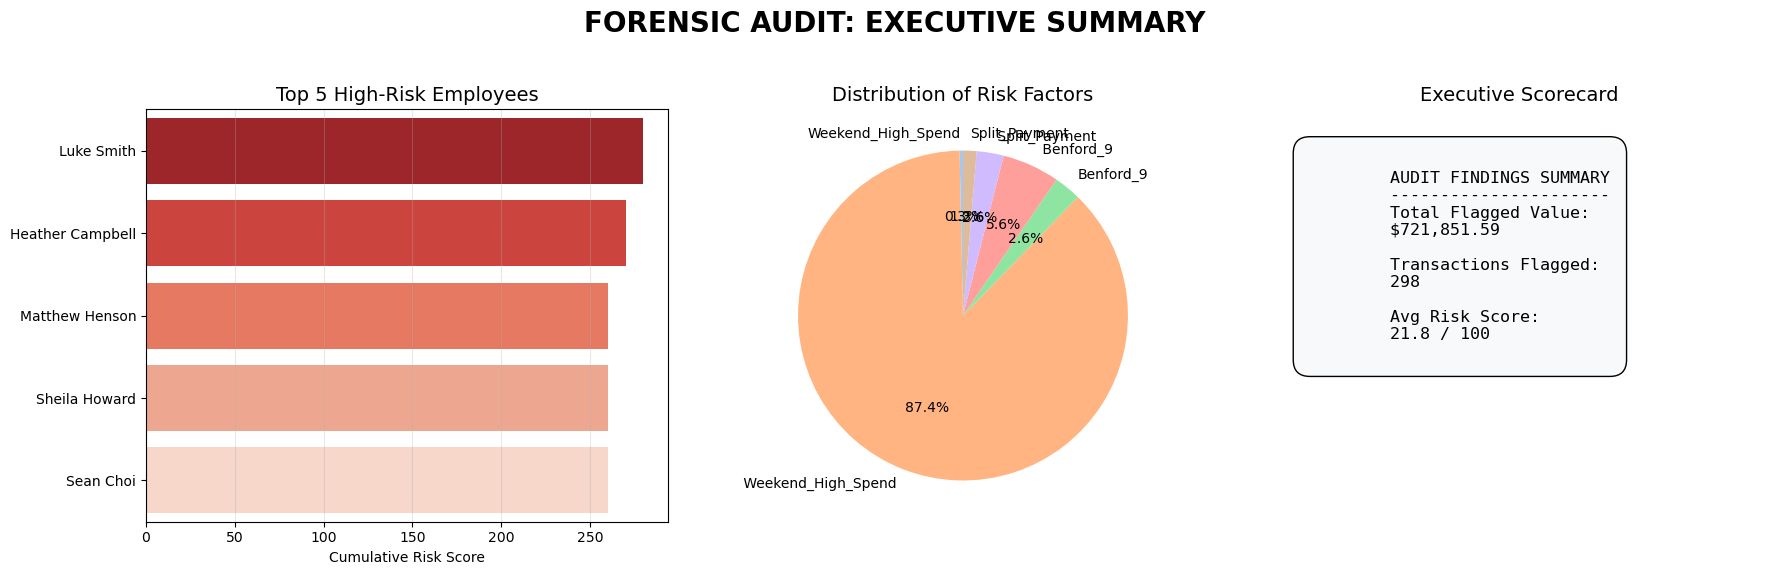

Dashboard generated successfully.


In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

print("--- BUILDING EXECUTIVE DASHBOARD ---")

# 1. LOAD THE DATA
if not os.path.exists('Scored_Transactions.csv'):
    print("ERROR: 'Scored_Transactions.csv' not found. Please re-run Chapter 8.")
else:
    df = pd.read_csv('Scored_Transactions.csv')
    
    # Filter for High Risk
    risky_df = df[df['Risk_Score'] > 0].copy()
    
    if risky_df.empty:
        print("NOTICE: No risky transactions found with Score > 0. Dashboard cannot be generated.")
    else:
        print(f"Loaded {len(risky_df)} high-risk transactions.")

        # 2. PREPARE THE DATA AGGREGATES
        # A. Top Employees
        top_employees = risky_df.groupby('Emp_Name')['Risk_Score'].sum().sort_values(ascending=False).head(5).reset_index()

        # B. Risk Breakdown (Parsing the 'Risk_Notes')
        from collections import Counter
        # Combine all notes into one long string
        all_notes = risky_df['Risk_Notes'].dropna().str.cat(sep=' ')
        # Split by the separator '; ' and count
        risk_counts = Counter([x for x in all_notes.split('; ') if x != ''])
        df_risk_types = pd.DataFrame.from_dict(risk_counts, orient='index', columns=['Count']).reset_index()
        df_risk_types.columns = ['Risk_Type', 'Count']

        # 3. GENERATE VISUALS
        plt.figure(figsize=(18, 6))
        plt.suptitle('FORENSIC AUDIT: EXECUTIVE SUMMARY', fontsize=20, weight='bold')

        # --- CHART 1: THE "HIT LIST" ---
        plt.subplot(1, 3, 1)
        sns.barplot(x='Risk_Score', y='Emp_Name', data=top_employees, palette='Reds_r')
        plt.title('Top 5 High-Risk Employees', fontsize=14)
        plt.xlabel('Cumulative Risk Score')
        plt.ylabel('')
        plt.grid(axis='x', alpha=0.3)

        # --- CHART 2: THE "CRIME MIX" ---
        plt.subplot(1, 3, 2)
        plt.pie(df_risk_types['Count'], labels=df_risk_types['Risk_Type'], autopct='%1.1f%%', 
                colors=sns.color_palette('pastel'), startangle=90)
        plt.title('Distribution of Risk Factors', fontsize=14)

        # --- CHART 3: FINANCIAL IMPACT ---
        plt.subplot(1, 3, 3)
        plt.axis('off')
        total_risk_value = risky_df['Amount'].sum()
        high_risk_count = len(risky_df)
        avg_score = risky_df['Risk_Score'].mean()

        text_content = f"""
        AUDIT FINDINGS SUMMARY
        ----------------------
        Total Flagged Value:
        ${total_risk_value:,.2f}

        Transactions Flagged:
        {high_risk_count}

        Avg Risk Score:
        {avg_score:.1f} / 100
        """
        plt.text(0.1, 0.4, text_content, fontsize=12, family='monospace', 
                 bbox=dict(facecolor='#f8f9fa', edgecolor='black', boxstyle='round,pad=1'))
        plt.title('Executive Scorecard', fontsize=14)

        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.show()
        
        print("Dashboard generated successfully.")